In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Jupyter/transactions_mapped01.csv")
df.columns = df.columns.str.strip()

# Convert datetime
df['Transaction Time'] = pd.to_datetime(df['Transaction Time'])

# Sort chronologically
df = df.sort_values('Transaction Time').reset_index(drop=True)

# Fraud label
df['FRAUD'] = df['Purpose'].apply(
    lambda x: 1 if x == "Fraud Transaction" else 0
)

# Convert Amount Spikes to binary
df['Amount_Spike_Flag'] = df['Amount Spikes'].apply(
    lambda x: 1 if str(x).strip().lower() == "yes" else 0
)

print("Total Records:", len(df))
print("Fraud Count:", df['FRAUD'].sum())

Total Records: 11611
Fraud Count: 16


In [2]:
# Hour feature
df['hour'] = df['Transaction Time'].dt.hour
df['is_night'] = df['hour'].apply(lambda x: 1 if 0 <= x <= 5 else 0)

# Time gap
df['time_gap_sec'] = df['Transaction Time'].diff().dt.total_seconds()
df['time_gap_sec'] = df['time_gap_sec'].fillna(0)

# Previous balance
df['prev_balance'] = df['Total Amt'].shift(1)
df['prev_balance'] = df['prev_balance'].fillna(df['Total Amt'])

# Balance drain %
df['balance_drain_pct'] = (
    (df['prev_balance'] - df['Total Amt']) / df['prev_balance']
)
df['balance_drain_pct'] = df['balance_drain_pct'].replace([np.inf,-np.inf],0)
df['balance_drain_pct'] = df['balance_drain_pct'].fillna(0)

In [3]:
# -------------------------------------------------
# IMPOSSIBLE TRAVEL DETECTION
# -------------------------------------------------

import math

city_coords = {
    "Koramangala": (12.9352, 77.6245),
    "Chennai": (13.0827, 80.2707),
    "Indiranagar": (12.9784, 77.6408),
    "Whitefield": (12.9698, 77.7500),
    "HSR Layout": (12.9116, 77.6474),
    "MG Road": (12.9758, 77.6046),
    "Jayanagar": (12.9250, 77.5938),
    "Malleshwaram": (13.0031, 77.5713),
    "Delhi": (28.6519, 77.2315),   
    "Bihar": (25.1948, 85.5170),    
    "Hyderabad": (17.3871, 78.4917), 
    "Pune": (18.5167, 73.8563),   
    "Kochi": (9.9312, 76.2673) 
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)

    a = (math.sin(dlat/2)**2 +
         math.cos(math.radians(lat1)) *
         math.cos(math.radians(lat2)) *
         math.sin(dlon/2)**2)

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

df['travel_speed_kmh'] = 0.0
df['travel_speed_kmh'] = df['travel_speed_kmh'].astype(float)

for i in range(1, len(df)):
    prev_city = df.loc[i-1, 'Location']
    curr_city = df.loc[i, 'Location']

    if prev_city in city_coords and curr_city in city_coords:
        lat1, lon1 = city_coords[prev_city]
        lat2, lon2 = city_coords[curr_city]

        distance = haversine(lat1, lon1, lat2, lon2)

        time_diff_hours = df.loc[i, 'time_gap_sec'] / 3600

        if time_diff_hours > 0:
            speed = distance / time_diff_hours
        else:
            speed = 0

        df.loc[i, 'travel_speed_kmh'] = speed

# Flag impossible travel (>500 km/h unrealistic)
df['impossible_travel_flag'] = (df['travel_speed_kmh'] > 500).astype(int)

In [4]:
# IP change
df['ip_change_flag'] = (
    df['Device IP'] != df['Device IP'].shift(1)
).astype(int)

# Location change
df['location_change_flag'] = (
    df['Location'] != df['Location'].shift(1)
).astype(int)

In [5]:
df['velocity_1h'] = 0

for i in range(len(df)):
    current_time = df.loc[i, 'Transaction Time']
    past_time = current_time - pd.Timedelta(hours=1)
    
    df.loc[i, 'velocity_1h'] = df[
        (df['Transaction Time'] >= past_time) &
        (df['Transaction Time'] <= current_time)
    ].shape[0]

In [6]:
normal_df = df[df['FRAUD']==0]

def compute_zscore(col):
    mean = normal_df[col].mean()
    std = normal_df[col].std()
    if std == 0:
        return np.zeros(len(df))
    return (df[col] - mean) / std

df['debit_zscore'] = compute_zscore('Debited Amt')
df['timegap_zscore'] = compute_zscore('time_gap_sec')
df['velocity_zscore'] = compute_zscore('velocity_1h')

In [7]:
anomaly_features = [
    'Debited Amt',
    'hour',
    'time_gap_sec',
    'velocity_1h',
    'balance_drain_pct',
    'ip_change_flag',
    'location_change_flag',
    'Amount_Spike_Flag'
]

X_normal = normal_df[anomaly_features]

scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)

iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(X_normal_scaled)

# Apply to full dataset
X_all_scaled = scaler.transform(df[anomaly_features])
df['anomaly_score'] = iso_model.decision_function(X_all_scaled)

# Convert to positive anomaly score
df['anomaly_score'] = -df['anomaly_score']

In [8]:
df['rule_score'] = 0

# Large amount rule
df.loc[df['debit_zscore'] > 3, 'rule_score'] += 40

# High balance drain
df.loc[df['balance_drain_pct'] > 0.5, 'rule_score'] += 50

# Night multiplier
df.loc[df['is_night'] == 1, 'rule_score'] += 10

# Identity instability
df.loc[df['ip_change_flag'] == 1, 'rule_score'] += 20
df.loc[df['location_change_flag'] == 1, 'rule_score'] += 20

# Velocity anomaly
df.loc[df['velocity_zscore'] > 3, 'rule_score'] += 30

# Impossible travel rule
df.loc[df['impossible_travel_flag'] == 1, 'rule_score'] += 50

In [9]:
# Normalize rule score
df['rule_score_norm'] = df['rule_score'] / df['rule_score'].max()

# Normalize anomaly score
df['anomaly_score_norm'] = (
    df['anomaly_score'] - df['anomaly_score'].min()
) / (df['anomaly_score'].max() - df['anomaly_score'].min())

# Final risk score
df['final_risk'] = (
    0.6 * df['anomaly_score_norm'] +
    0.4 * df['rule_score_norm']
)

In [10]:
def decision_engine(risk):
    if risk < 0.3:
        return "ALLOW"
    elif risk < 0.7:
        return "OTP_REQUIRED"
    else:
        return "BLOCK"

df['decision'] = df['final_risk'].apply(decision_engine)

print(df[['Debited Amt','FRAUD','final_risk','decision']].head(20))

    Debited Amt  FRAUD  final_risk      decision
0             0      0    0.224028         ALLOW
1          3161      0    0.537083  OTP_REQUIRED
2           425      0    0.286760         ALLOW
3          2071      0    0.414855  OTP_REQUIRED
4             0      0    0.400372  OTP_REQUIRED
5             0      0    0.179059         ALLOW
6          2032      0    0.439529  OTP_REQUIRED
7          1834      0    0.316051  OTP_REQUIRED
8           630      0    0.298233         ALLOW
9          1122      0    0.506145  OTP_REQUIRED
10         7219      0    0.809834         BLOCK
11         1247      0    0.389787  OTP_REQUIRED
12            0      0    0.446712  OTP_REQUIRED
13          622      0    0.409048  OTP_REQUIRED
14          484      0    0.259836         ALLOW
15         2414      0    0.511161  OTP_REQUIRED
16            0      0    0.224036         ALLOW
17         1685      0    0.516084  OTP_REQUIRED
18            0      0    0.245304         ALLOW
19         1416     

In [11]:
# ==================================================
# PHASE 9.5A — IP SPOOFING SIMULATION LAYER
# ==================================================

import random

# Known risky IPs (simulated blacklist)
blacklisted_ips = [
    "8.8.8.8",
    "192.168.0.66",
    "10.0.0.13"
]

def ip_spoofing_check(device_ip, ip_change_flag):
    spoof_flag = 0
    spoof_reason = None
    
    # If IP is blacklisted
    if device_ip in blacklisted_ips:
        spoof_flag = 1
        spoof_reason = "IP address found in blacklist database"
    
    # Rapid IP change (possible spoofing)
    elif ip_change_flag == 1 and random.random() > 0.7:
        spoof_flag = 1
        spoof_reason = "Rapid IP change detected — possible IP spoofing"
    
    return spoof_flag, spoof_reason

In [12]:
# ==================================================
# PHASE 9.5B — NETWORK LATENCY SIMULATION
# ==================================================

def simulate_latency():
    # Simulate latency in milliseconds
    latency = random.randint(20, 1500)
    latency_flag = 0
    latency_reason = None
    
    # Suspicious if too high
    if latency > 1000:
        latency_flag = 1
        latency_reason = "Unusual network latency detected (possible VPN / proxy)"
    
    return latency, latency_flag, latency_reason

In [13]:
# ==================================================
# PHASE 9.5C — BANK CONSTRAINT SIMULATION
# ==================================================

DAILY_LIMIT = 100000
PER_TRANSACTION_LIMIT = 100000
ACCOUNT_BALANCE = df['Total Amt'].iloc[-1]  # simulated balance

def bank_constraints_check(debit_amt, final_risk):
    
    block_flag = 0
    otp_flag = 0
    constraint_reasons = []
    
    # 1️⃣ Per transaction limit
    if debit_amt > PER_TRANSACTION_LIMIT:
        block_flag = 1
        constraint_reasons.append("Amount exceeds per-transaction limit")
    
    # 2️⃣ Insufficient balance
    if debit_amt > ACCOUNT_BALANCE:
        block_flag = 1
        constraint_reasons.append("Insufficient account balance")
    
    # 3️⃣ Daily limit breach (simulate)
    simulated_daily_spend = random.randint(0, 250000)
    if simulated_daily_spend + debit_amt > DAILY_LIMIT:
        otp_flag = 1
        constraint_reasons.append("Daily transaction limit approaching")
    
    # 4️⃣ High risk override
    if final_risk > 0.8:
        block_flag = 1
        constraint_reasons.append("Critical AI risk score detected")
    
    return block_flag, otp_flag, constraint_reasons

In [14]:
# ==================================================
# EXPLAINABILITY LAYER (DOES NOT CHANGE METRICS)
# ==================================================

def generate_reasons(row):
    reasons = []
    
    if row['debit_zscore'] > 3:
        reasons.append("Unusually large transaction amount detected (High Z-Score)")
        
    if row['balance_drain_pct'] > 0.5:
        reasons.append("Transaction drains more than 50% of account balance")
        
    if row['is_night'] == 1:
        reasons.append("Transaction occurred during unusual night hours")
        
    if row['ip_change_flag'] == 1:
        reasons.append("Device IP changed from previous transaction")
        
    if row['location_change_flag'] == 1:
        reasons.append("Transaction location changed from previous location")
        
    if row['velocity_zscore'] > 3:
        reasons.append("High transaction frequency detected within 1 hour")
        
    if row['impossible_travel_flag'] == 1:
        reasons.append("Impossible travel detected (Unrealistic travel speed > 500 km/h)")
        
    if row['Amount_Spike_Flag'] == 1:
        reasons.append("Transaction marked as sudden amount spike")
        
    return reasons

In [15]:
df['risk_reasons'] = df.apply(generate_reasons, axis=1)

In [16]:
def print_transaction_decision(index):
    
    row = df.loc[index]
    
    print("Transaction ID:", row['TransactionID'])
    print("Final Risk Score:", round(row['final_risk'], 3))
    print("Decision:", row['decision'])
    print("Predicted Fraud:", row['predicted_fraud'])
    print("\n--- Risk Factors Detected ---")
    
    if len(row['risk_reasons']) == 0:
        print("No significant anomaly detected.")
    else:
        for r in row['risk_reasons']:
            print("•", r)
            
    if row['decision'] == "OTP_REQUIRED":
        print("\nReason: Medium risk behavior detected. Authentication required.")
        
    if row['decision'] == "BLOCK":
        print("\nReason: Critical risk pattern detected. Transaction blocked for security.")

In [17]:
# Choose threshold
threshold = 0.65

df['predicted_fraud'] = (df['final_risk'] >= threshold).astype(int)

In [18]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc
)

y_true = df['FRAUD']
y_pred = df['predicted_fraud']
y_prob = df['final_risk']

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:\n", cm)
print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

# Fraud Capture Rate (Recall)
fraud_capture_rate = tp / (tp + fn)
print("\nFraud Capture Rate:", fraud_capture_rate)

# False Positive Rate
false_positive_rate = fp / (fp + tn)
print("False Positive Rate:", false_positive_rate)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_true, y_prob)
print("ROC-AUC:", roc_auc)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

Confusion Matrix:
 [[11515    80]
 [    0    16]]

True Negatives: 11515
False Positives: 80
False Negatives: 0
True Positives: 16

Fraud Capture Rate: 1.0
False Positive Rate: 0.0068995256576110395

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     11595
           1       0.17      1.00      0.29        16

    accuracy                           0.99     11611
   macro avg       0.58      1.00      0.64     11611
weighted avg       1.00      0.99      1.00     11611

ROC-AUC: 0.9988249245364381
PR-AUC: 0.6783732355050827


In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix

print("Threshold | Recall | FPR | Precision")

for t in np.arange(0.1, 0.9, 0.05):
    df['pred_temp'] = (df['final_risk'] >= t).astype(int)
    
    cm = confusion_matrix(y_true, df['pred_temp'])
    tn, fp, fn, tp = cm.ravel()
    
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"{t:.2f}       | {recall_val:.2f}   | {fpr_val:.4f} | {precision_val:.2f}")

Threshold | Recall | FPR | Precision
0.10       | 1.00   | 0.7173 | 0.00
0.15       | 1.00   | 0.4606 | 0.00
0.20       | 1.00   | 0.3532 | 0.00
0.25       | 1.00   | 0.2399 | 0.01
0.30       | 1.00   | 0.1683 | 0.01
0.35       | 1.00   | 0.1073 | 0.01
0.40       | 1.00   | 0.0699 | 0.02
0.45       | 1.00   | 0.0455 | 0.03
0.50       | 1.00   | 0.0281 | 0.05
0.55       | 1.00   | 0.0187 | 0.07
0.60       | 1.00   | 0.0123 | 0.10
0.65       | 1.00   | 0.0069 | 0.17
0.70       | 0.81   | 0.0034 | 0.25
0.75       | 0.81   | 0.0014 | 0.45
0.80       | 0.38   | 0.0003 | 0.60
0.85       | 0.38   | 0.0001 | 0.86


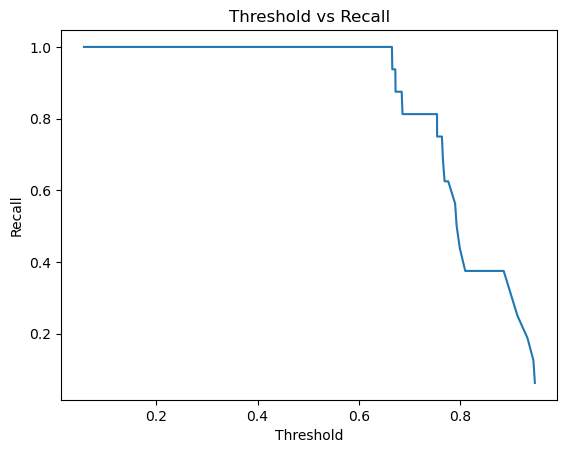

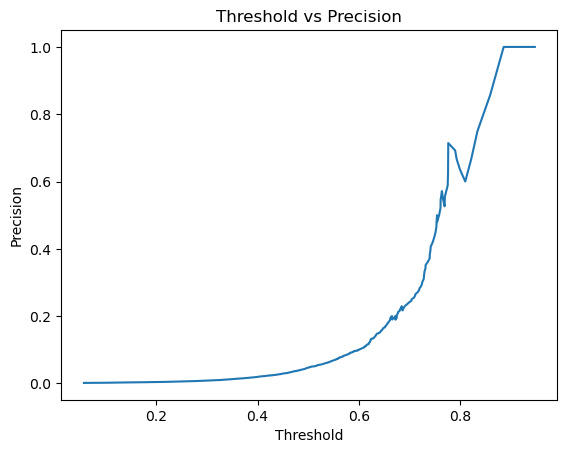

In [20]:
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

plt.plot(thresholds, recall[:-1])
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.show()

plt.plot(thresholds, precision[:-1])
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Threshold vs Precision")
plt.show()

In [21]:
# False Negatives (actual fraud but predicted normal)
false_negatives = df[(df['FRAUD'] == 1) & (df['predicted_fraud'] == 0)]

print("Number of Missed Frauds:", len(false_negatives))
false_negatives

Number of Missed Frauds: 0


,Device IP,TransactionID,Transaction Time,Location,Type,Purpose,Amount Spikes,Debited Amt,Credited Amt,Total Amt,...,velocity_zscore,anomaly_score,rule_score,rule_score_norm,anomaly_score_norm,final_risk,decision,risk_reasons,predicted_fraud,pred_temp


In [22]:
true_positives = df[(df['FRAUD'] == 1) & (df['predicted_fraud'] == 1)]

print("True Positives:", len(true_positives))
print("False Negatives:", len(false_negatives))

True Positives: 16
False Negatives: 0


In [23]:
cols_to_compare = [
    'Debited Amt',
    'debit_zscore',
    'anomaly_score_norm',
    'rule_score',
    'ip_change_flag',
    'location_change_flag',
    'velocity_1h',
    'balance_drain_pct'
]

print("---- TRUE POSITIVES ----")
print(true_positives[cols_to_compare].describe())

print("\n---- FALSE NEGATIVES ----")
print(false_negatives[cols_to_compare].describe())

---- TRUE POSITIVES ----
         Debited Amt  debit_zscore  anomaly_score_norm  rule_score  \
count      16.000000     16.000000           16.000000   16.000000   
mean   117627.000000    127.176139            0.875058  100.000000   
std    104254.103695    113.169556            0.096763   23.380904   
min      1500.000000      1.118357            0.679895   80.000000   
25%     45000.000000     48.338327            0.884933   80.000000   
50%     89436.500000     96.574884            0.898841   90.000000   
75%    200000.000000    216.593395            0.912277  107.500000   
max    342569.000000    371.354406            1.000000  140.000000   

       ip_change_flag  location_change_flag  velocity_1h  balance_drain_pct  
count       16.000000             16.000000       16.000          16.000000  
mean         0.875000              0.875000        1.375           0.448725  
std          0.341565              0.341565        0.500           0.387876  
min          0.000000           

In [24]:
import pandas as pd
import numpy as np

print("TOTAL TRANSACTIONS:", len(df))
print("TOTAL FRAUD:", df['FRAUD'].sum())
print("FRAUD RATIO:", df['FRAUD'].mean())

print("\nAverage Debit:", df['Debited Amt'].mean())
print("95th Percentile Debit:", df['Debited Amt'].quantile(0.95))
print("Max Debit:", df['Debited Amt'].max())

TOTAL TRANSACTIONS: 11611
TOTAL FRAUD: 16
FRAUD RATIO: 0.0013780036172594953

Average Debit: 631.1901644991818
95th Percentile Debit: 2453.5
Max Debit: 342569


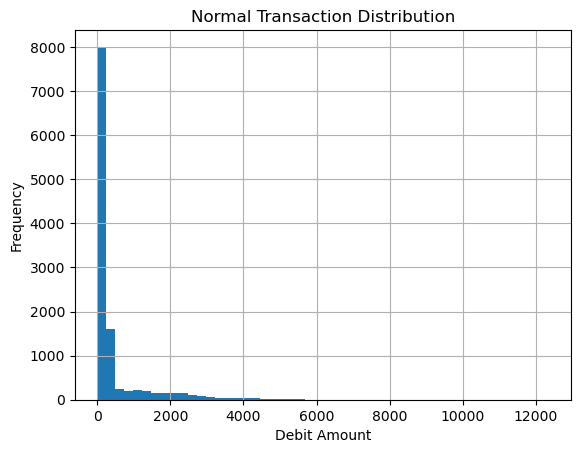

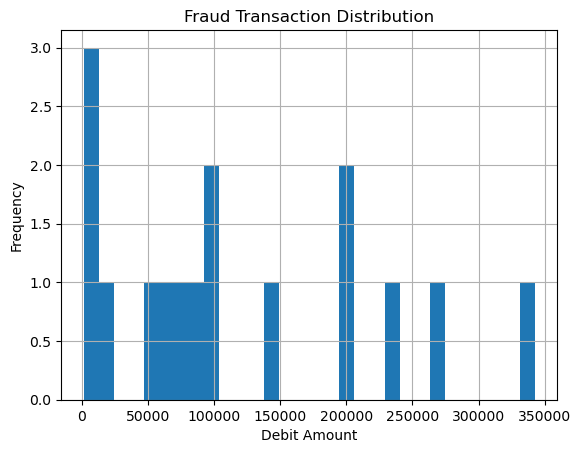

In [25]:
import matplotlib.pyplot as plt

plt.figure()
df[df['FRAUD']==0]['Debited Amt'].hist(bins=50)
plt.title("Normal Transaction Distribution")
plt.xlabel("Debit Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df[df['FRAUD']==1]['Debited Amt'].hist(bins=30)
plt.title("Fraud Transaction Distribution")
plt.xlabel("Debit Amount")
plt.ylabel("Frequency")
plt.show()

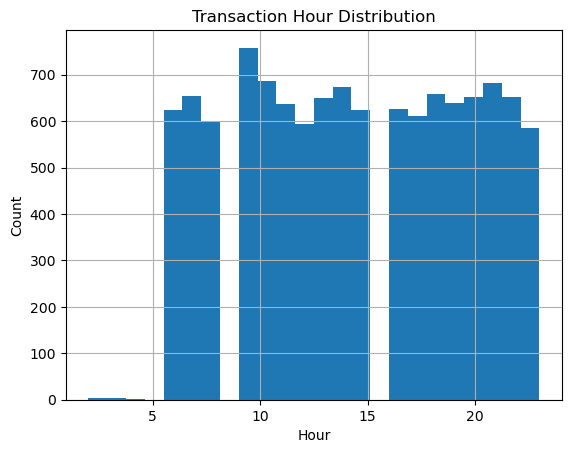

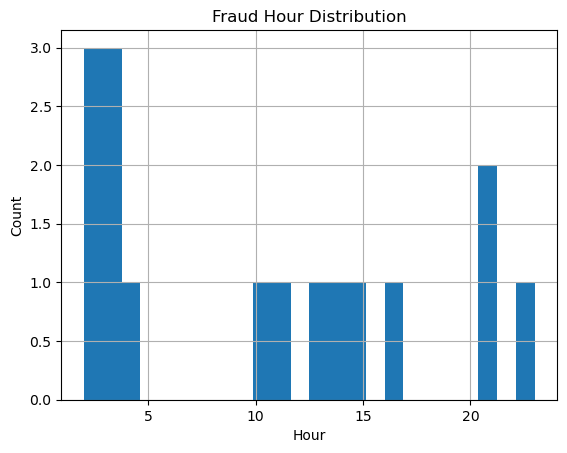

In [26]:
df['hour'] = df['Transaction Time'].dt.hour

plt.figure()
df['hour'].hist(bins=24)
plt.title("Transaction Hour Distribution")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

plt.figure()
df[df['FRAUD']==1]['hour'].hist(bins=24)
plt.title("Fraud Hour Distribution")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

In [27]:
print(df[df['FRAUD']==1]['Location'].value_counts())

print("Fraud with Location Change:",
      df[(df['FRAUD']==1) & (df['location_change_flag']==1)].shape[0])

print("Fraud with Impossible Travel:",
      df[(df['FRAUD']==1) & (df['impossible_travel_flag']==1)].shape[0])

Location
Unknown                   8
Online / International    1
Whitefield                1
Kochi                     1
Pune                      1
Delhi                     1
Bihar                     1
Chennai                   1
Mumbai                    1
Name: count, dtype: int64
Fraud with Location Change: 14
Fraud with Impossible Travel: 3


In [28]:
fraud_df = df[df['FRAUD']==1]
normal_df = df[df['FRAUD']==0]

print("Fraud IP Change Rate:",
      fraud_df['ip_change_flag'].mean())

print("Normal IP Change Rate:",
      normal_df['ip_change_flag'].mean())

print("Fraud Location Change Rate:",
      fraud_df['location_change_flag'].mean())

print("Normal Location Change Rate:",
      normal_df['location_change_flag'].mean())

Fraud IP Change Rate: 0.875
Normal IP Change Rate: 0.21871496334626994
Fraud Location Change Rate: 0.875
Normal Location Change Rate: 0.871237602414834


In [29]:
total_fraud_loss = fraud_df['Debited Amt'].sum()
avg_fraud_loss = fraud_df['Debited Amt'].mean()

print("Total Fraud Loss:", total_fraud_loss)
print("Average Fraud Loss:", avg_fraud_loss)
print("Max Fraud Loss:", fraud_df['Debited Amt'].max())

Total Fraud Loss: 1882032
Average Fraud Loss: 117627.0
Max Fraud Loss: 342569


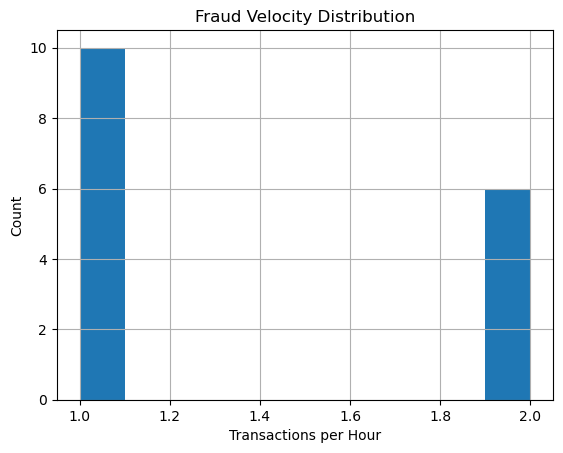

In [30]:
plt.figure()
fraud_df['velocity_1h'].hist(bins=10)
plt.title("Fraud Velocity Distribution")
plt.xlabel("Transactions per Hour")
plt.ylabel("Count")
plt.show()

In [31]:
df['fraud_type'] = "Normal"

df.loc[(df['FRAUD']==1) & (df['Debited Amt'] > 50000),
       'fraud_type'] = "High Value"

df.loc[(df['FRAUD']==1) & (df['Debited Amt'] <= 50000),
       'fraud_type'] = "Micro Fraud"

df.loc[(df['FRAUD']==1) & (df['impossible_travel_flag']==1),
       'fraud_type'] = "Impossible Travel"

print(df[df['FRAUD']==1]['fraud_type'].value_counts())

fraud_type
High Value           12
Impossible Travel     3
Micro Fraud           1
Name: count, dtype: int64


In [32]:
cost_per_fraud = 50000
cost_per_false_positive = 100

expected_loss = (fn * cost_per_fraud) + (fp * cost_per_false_positive)

print("Estimated Operational Loss:", expected_loss)

Estimated Operational Loss: 500100


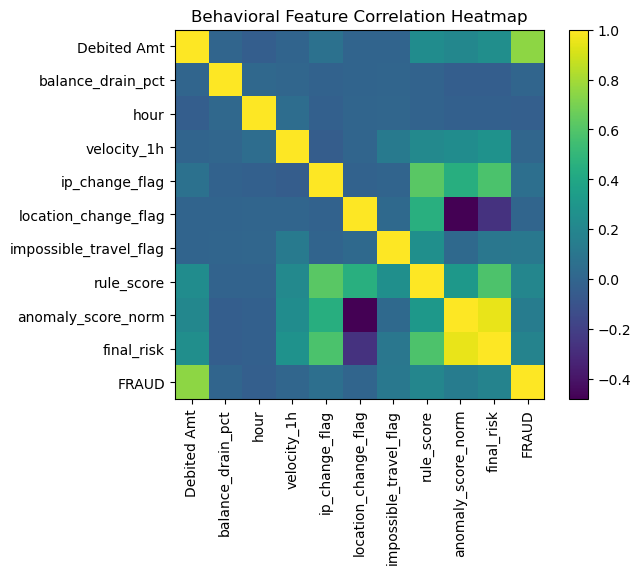

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Select numeric behavioral features
features = [
    'Debited Amt',
    'balance_drain_pct',
    'hour',
    'velocity_1h',
    'ip_change_flag',
    'location_change_flag',
    'impossible_travel_flag',
    'rule_score',
    'anomaly_score_norm',
    'final_risk',
    'FRAUD'
]

corr = df[features].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title("Behavioral Feature Correlation Heatmap")
plt.show()

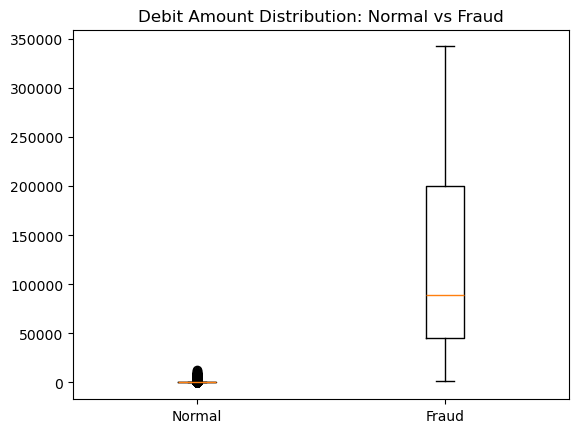

In [34]:
# 📊 Debit Amount Separation
plt.figure()
plt.boxplot([
    df[df['FRAUD']==0]['Debited Amt'],
    df[df['FRAUD']==1]['Debited Amt']
])
plt.xticks([1,2], ['Normal','Fraud'])
plt.title("Debit Amount Distribution: Normal vs Fraud")
plt.show()

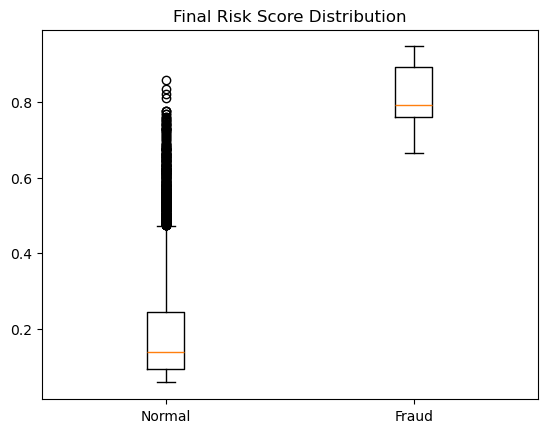

In [35]:
# 📊 Risk Score Separation
plt.figure()
plt.boxplot([
    df[df['FRAUD']==0]['final_risk'],
    df[df['FRAUD']==1]['final_risk']
])
plt.xticks([1,2], ['Normal','Fraud'])
plt.title("Final Risk Score Distribution")
plt.show()

FRAUD          0   1
risk_band           
Critical       4   6
High          76  10
Low        10785   0
Medium       730   0


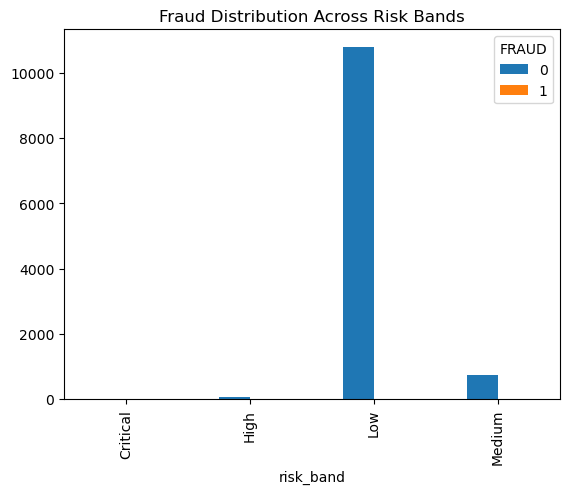

In [36]:
def risk_band(score):
    if score < 0.4:
        return "Low"
    elif score < 0.65:
        return "Medium"
    elif score < 0.8:
        return "High"
    else:
        return "Critical"

df['risk_band'] = df['final_risk'].apply(risk_band)

band_analysis = df.groupby(['risk_band','FRAUD']).size().unstack(fill_value=0)

print(band_analysis)

band_analysis.plot(kind='bar')
plt.title("Fraud Distribution Across Risk Bands")
plt.show()

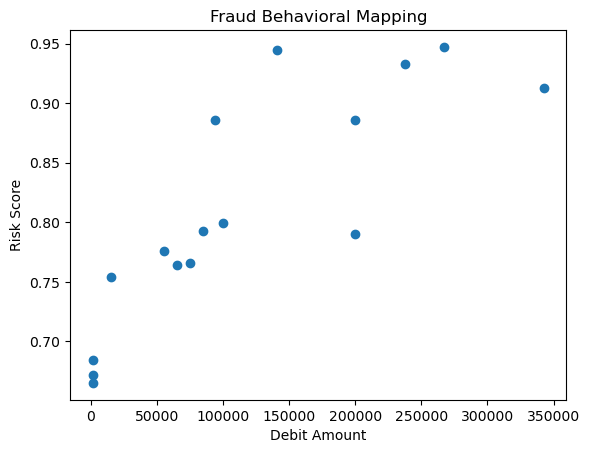

In [37]:
fraud_df = df[df['FRAUD']==1]

plt.figure()
plt.scatter(fraud_df['Debited Amt'], fraud_df['final_risk'])
plt.xlabel("Debit Amount")
plt.ylabel("Risk Score")
plt.title("Fraud Behavioral Mapping")
plt.show()